In [ ]:
import numpy as np
import pandas as pd


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load your dataset
df = pd.read_csv('/content/merged_dataset_after_data_preprocessing.csv')

print(df.shape)
df.head()

(144233, 613)


,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_13,...,id_38_freq,DeviceType_freq,DeviceInfo_freq,ProductCD_freq,card4_freq,card6_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,isFraud
0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,...,0.511362,0.380202,0.000078,0.250039,0.295469,0.523504,0.376614,0.105559,0.596650,0
1,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,100.0,49.0,...,0.511362,0.380202,0.144004,0.250039,0.626948,0.475794,0.125578,0.105559,0.596650,0
2,-5.0,191631.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,52.0,...,0.511362,0.596728,0.331106,0.415146,0.295469,0.523504,0.376614,0.375600,0.069913,0
3,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,100.0,52.0,...,0.511362,0.596728,0.171884,0.415146,0.295469,0.475794,0.177197,0.170558,0.069913,0
4,0.0,7460.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,NaN,...,0.511362,0.596728,0.091233,0.250039,0.626948,0.475794,0.032188,0.105559,0.596650,0


In [ ]:
# Sort by time
df = df.sort_values('TransactionDT').reset_index(drop=True)

# Example: 80% train, 20% test
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(train_df.shape, test_df.shape)

(115386, 613) (28847, 613)


In [ ]:
drop_cols = ['isFraud', 'TransactionDT', 'rule_score','TransactionID' ]

features = [col for col in df.columns if col not in drop_cols]

X_train = train_df[features]
X_test  = test_df[features]

In [ ]:
non_numeric_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(non_numeric_cols)

Index([], dtype='object')


In [ ]:
X_train = X_train.drop(columns=non_numeric_cols)
X_test  = X_test.drop(columns=non_numeric_cols)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
fraud_rate = train_df['isFraud'].mean()
print("Fraud rate in train:", fraud_rate)

Fraud rate in train: 0.07493110082679008


In [ ]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.09,
    random_state=42,
    n_jobs=-1
)

In [ ]:
iso.fit(X_train_scaled)
train_df['iso_score'] = -iso.decision_function(X_train_scaled)
test_df['iso_score']  = -iso.decision_function(X_test_scaled)

In [ ]:
final_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

In [ ]:
# Bin iso_score
final_df['iso_bin'] = pd.qcut(final_df['iso_score'], q=10, duplicates='drop')

fraud_rate = final_df.groupby('iso_bin')['isFraud'].mean()

print(fraud_rate)

iso_bin
(-0.0835, -0.0776]     0.012479
(-0.0776, -0.0735]     0.015531
(-0.0735, -0.0659]     0.027803
(-0.0659, -0.0619]     0.035152
(-0.0619, -0.0569]     0.048114
(-0.0569, -0.0485]     0.080150
(-0.0485, -0.0359]     0.127089
(-0.0359, -0.0172]     0.170908
(-0.0172, 0.000199]    0.124870
(0.000199, 0.127]      0.142610
Name: isFraud, dtype: float64


/tmp/ipykernel_22126/510137617.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = final_df.groupby('iso_bin')['isFraud'].mean()


/tmp/ipykernel_22126/2403703849.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = final_df.groupby('iso_bin')['isFraud'].mean()


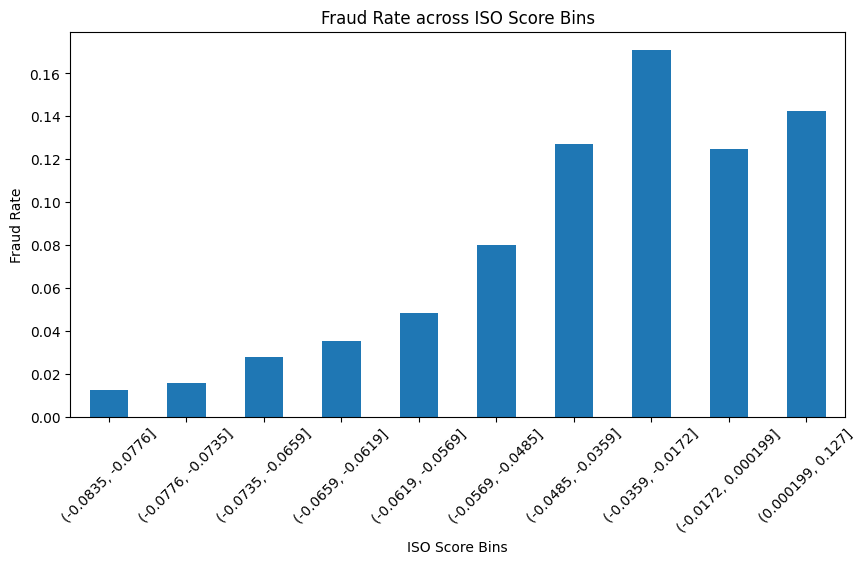

In [ ]:
import matplotlib.pyplot as plt

# Bin scores
final_df['iso_bin'] = pd.qcut(final_df['iso_score'], q=10, duplicates='drop')

fraud_rate = final_df.groupby('iso_bin')['isFraud'].mean()

# Plot
fraud_rate.plot(kind='bar', figsize=(10,5))

plt.title("Fraud Rate across ISO Score Bins")
plt.xlabel("ISO Score Bins")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_22126/821602665.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iso_trend = final_df.groupby('iso_bin')['isFraud'].mean().reset_index()


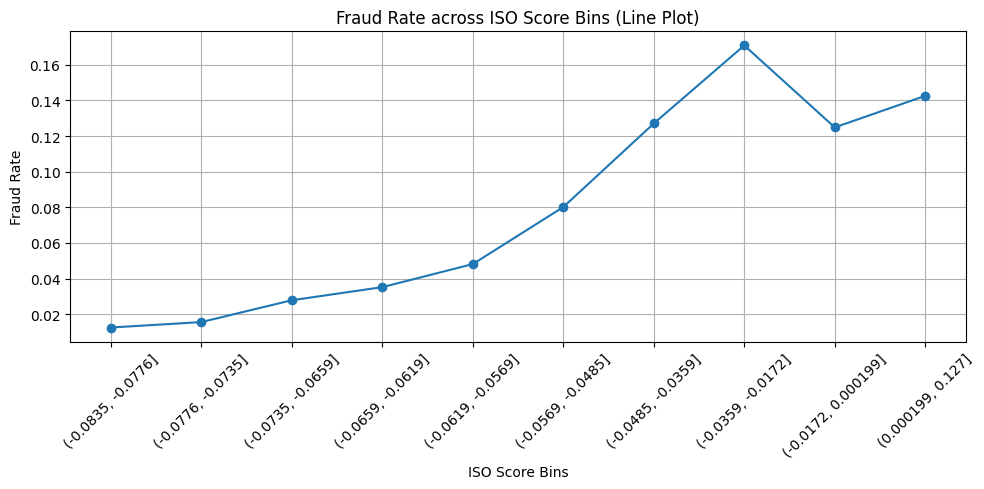

In [ ]:
import matplotlib.pyplot as plt

# Group by iso_bin (same as before)
iso_trend = final_df.groupby('iso_bin')['isFraud'].mean().reset_index()

# Convert bins to string for plotting
iso_trend['iso_bin'] = iso_trend['iso_bin'].astype(str)

# Plot
plt.figure(figsize=(10,5))
plt.plot(iso_trend['iso_bin'], iso_trend['isFraud'], marker='o')

plt.xticks(rotation=45)
plt.xlabel("ISO Score Bins")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate across ISO Score Bins (Line Plot)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
final_df.to_csv('/content/fraud_final_with_Iso_score.csv', index=False)